### LFP data of rat OB 
At baseline, and with ketamine or saline injection.

20 min baseline rec. + i.p. injection of 20mg/kg ketamine or saline(ctrl) + 60 min rec. post injection. 
Injection is at ~time = 1200 s.

https://scientificallysound.org/2018/04/05/import-spike2-into-python/

https://neo.readthedocs.io/en/latest/iolist.html#neo.io.Spike2IO


In [1]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import pandas as pd
import neo
from neo.io import *

import numpy as np
import os
import quantities as pq
from matplotlib import pyplot
import pywt # pip install pywavelets
from scipy.signal import butter, lfilter
from lfp_analysis import *

In [2]:
def load_lfp_data(results_dir, file_name):
    #cwd = os.getcwd()
    #ob_dir = os.path.dirname(cwd)
    
    # create a reader
    reader = neo.io.Spike2IO(filename=os.path.join(results_dir, file_name), try_signal_grouping=False)

    # read the block
    data = reader.read()[0]
    
    times_list = []
    signals_list = []
    channels_list = []
    for i, asig in enumerate(data.segments[0].analogsignals):
        # Check if 'title' exists in annotations, otherwise use a default name
        chan = asig.annotations.get('title', f'channel_{i}')
        if isinstance(chan, bytes):
            chan = chan.decode('utf-8')
            # Determine channel name, without leading b' 
            #chan = str(asig.annotations['title']).split(sep="'")[1]
        channels_list.append(chan)
        sampling_rate = float(asig.sampling_rate)   # 5000 Hz
        dt = 1 / (sampling_rate * 0.01)    # in ms
        
    for seg in data.segments:
        for i, asig in enumerate(seg.analogsignals):
                times = asig.times.rescale("s").magnitude
                times_list.append(times)
                asig = asig.magnitude
                signals_list.append(asig)

    data_dict = {"channel": channels_list, "times": times_list, "sig_vals": signals_list}
    df = pd.DataFrame(data_dict, columns=['channel', 'times', 'sig_vals'])
    df = df.set_index('channel')
    df.sort_index(inplace = True)
                
                
    return data, dt, df, times_list

In [3]:
def plot_all_channels(results_dir, file_name):
    #, t1=1250, t2=1500
    data, dt, df, times_list = load_lfp_data(results_dir, file_name)
    
    for seg in data.segments:
        print("SEG: " + str(seg.file_origin))
        
        nrow = 4; ncol = 1;
        fig, axs = plt.subplots(nrows=nrow, ncols=ncol)
        fig.set_size_inches(8, 10)
        fig.suptitle(seg.file_origin)
        
        
        for i, ax in enumerate(fig.axes):    
            channel = df.iloc[i].name
            ax.plot(df.iloc[i]['times'], df.iloc[i]['sig_vals'])
            #ax.set_xlim(t1, t2)
            
            ax.set_ylabel(f'channel:{channel}')
    

In [4]:
def get_channel_data(data, channel_index):
       
    for seg in data.segments:
        for i, asig in enumerate(seg.analogsignals):
            if channel_index == i:
                times = asig.times.rescale("s").magnitude
                asig = asig.magnitude
            else:
                pass
    #if (channel_index==0) != (channel_index==1):
    
    return times, asig

In [5]:
# ketamine data
ket = ['Rat_42_KET_16_04_19.smr', 'Rat_43_KET_16_04_19.smr', 'Rat_44_KET_12_04_19.smr', 'Rat_45_KET_11_04_19.smr']

# saline data
sal = ['Rat_6_SAL_syst_26_01_24.smr', 'Rat_7_SAL_syst_26_01_24.smr', 'Rat_8_SAL_syst_26_01_24.smr', 'Rat_42_SAL_11_04_19.smr', 'Rat_43_SAL_12_04_19.smr', 'Rat_44_SAL_15_04_19.smr']

# baseline data
bl = ['Rat_222_BL_1_29_09_22.smr', 'Rat_223_BL_1_29_09_22.smr', 'Rat_224_BL_1_29_09_22.smr', 'Rat_225_BL_1_29_09_22.smr', 'Rat_234_BL1_14_11_22.smr', 'Rat_235_BL1_14_11_22.smr', 'Rat_236_BL1_14_11_22.smr', 'Rat_238_BL1_14_11_22.smr']

In [6]:
sim_dur = []
ket_results_dir = '/home/ellismith/OlfactoryBulb-1/hunt_data_smr/KET'
for ket_file in ket:
    data, dt, df, times_list = load_lfp_data(ket_results_dir, ket_file)
    last_t = times_list[0][-1]
    sim_dur.append(last_t)


In [7]:
sim_dur_sal = []
sal_results_dir = '/home/ellismith/OlfactoryBulb-1/hunt_data_smr/SAL'
for sal_file in sal:
    data, dt, df, times_list = load_lfp_data(sal_results_dir, sal_file)
    last_t = times_list[0][-1]
    sim_dur_sal.append(last_t)
sim_dur_sal

[6820.256, 6737.5524, 6769.275, 5165.9634, 5314.2768, 5358.5416]

In [8]:
sim_dur_bl = []
bl_results_dir = '/home/ellismith/OlfactoryBulb-1/hunt_data_smr/BL'
for bl_file in bl:
    data, dt, df, times_list = load_lfp_data(bl_results_dir, bl_file)
    last_t = times_list[0][-1]
    sim_dur_bl.append(last_t)
sim_dur_bl

[2157.646,
 1254.2252,
 1205.4034,
 1458.7666,
 1285.3864,
 1794.1438,
 1351.3606,
 1361.9072]

SEG: /home/ellismith/OlfactoryBulb-1/hunt_data_smr/KET/Rat_42_KET_16_04_19.smr


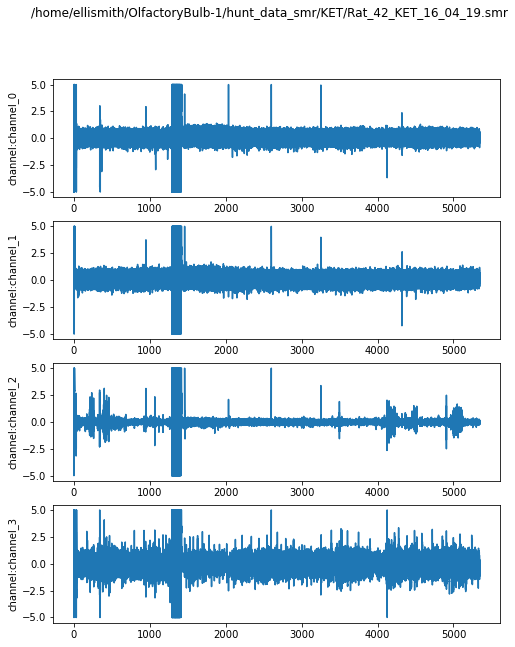

In [11]:
# one ketamine trial
plot_all_channels(ket_results_dir, ket[0])

SEG: /home/ellismith/OlfactoryBulb-1/hunt_data_smr/SAL/Rat_6_SAL_syst_26_01_24.smr


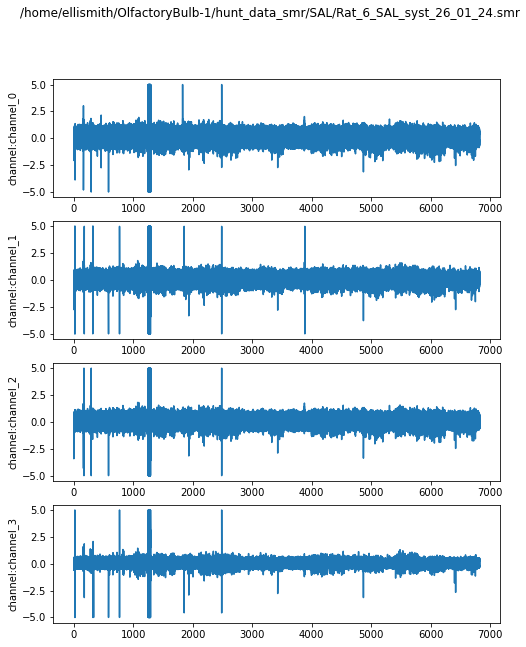

In [12]:
# one saline trial
plot_all_channels(sal_results_dir, sal[0])

SEG: /home/ellismith/OlfactoryBulb-1/hunt_data_smr/BL/Rat_222_BL_1_29_09_22.smr


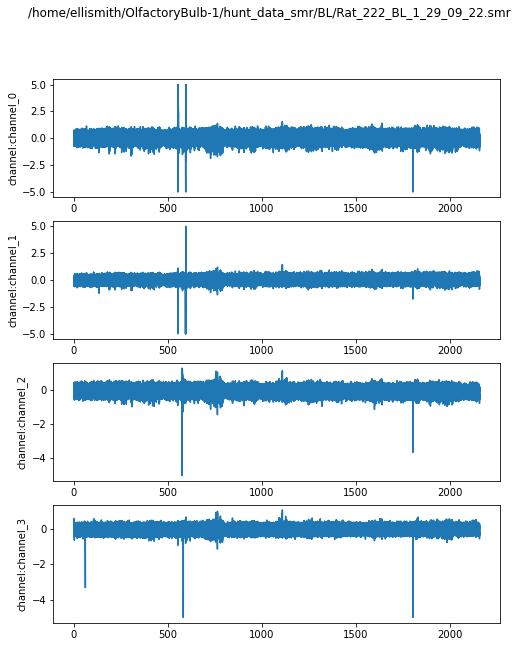

In [13]:
# one baseline trial
plot_all_channels(bl_results_dir, bl[0])